# What makes an ordinary street look like this city?

**Research question — can a trained visual encoder discover what makes ordinary
street scenes distinctive of a city, and can we distinguish genuine visual
structure from dataset shortcuts?**

The second half of that question is not decoration. Most of the work below is
spent establishing whether a 90% city classifier has learned anything about
cities at all.

**The assessed model is trained here from random initialisation** — a timm
ResNet50 on 100,000 street-level images from 20 cities. No pretrained SAM,
CLIP, Florence-2, YOLO or diffusion model does any of the work.

### Reported results come from the full local run

Every number below comes from a full run on a local RTX 3080 Ti. Training is
~75 minutes; the self-supervised comparison run was ~54 hours.
`TRAIN_FROM_SCRATCH` defaults to `False` and loads the published checkpoint and
cached embeddings, so this notebook reproduces the *reported* numbers exactly.
Setting it to `True` genuinely retrains on a Colab T4 with a reduced config,
but that shorter run will not reproduce the headline figures.

### What this notebook does not do

It does not present a tidy success. Along the way we hit a failed retrieval
objective, a self-inflicted evaluation bug, a self-supervised model that did
not beat an untrained baseline, and a first campaign test that turned out to be
contaminated. All four are kept, because each one changed what we could
honestly claim.

In [1]:
TRAIN_FROM_SCRATCH = False   # True genuinely retrains on a T4 with a reduced config

In [2]:
import os, sys, subprocess
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    if not os.path.exists("acv_training"):
        subprocess.run(["git", "clone", "https://github.com/<user>/acv_training.git"], check=False)
    os.chdir("acv_training")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "timm==1.0.26", "umap-learn", "grad-cam"], check=False)
sys.path.insert(0, os.getcwd())

import json
from pathlib import Path
import numpy as np, pandas as pd, torch, timm, torchvision
from IPython.display import Image, display

pd.set_option("display.width", 200)
print("torch", torch.__version__, "| torchvision", torchvision.__version__,
      "| timm", timm.__version__)
print("CUDA:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU only")

/home/dh/Project/person_projects/acv_training/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch 2.10.0+cu128 | torchvision 0.25.0+cu128 | timm 1.0.26
CUDA: NVIDIA GeForce RTX 3080 Ti Laptop GPU


---
## 1. Problem and motivation

Cities look different from one another, and not only through landmarks. Anyone
who has walked an unfamiliar city recognises something in the *ordinary* street:
the density of the canopy, how buildings meet the pavement, the width and
marking of the carriageway, the street furniture, the quality of the light.

This project asks whether a convolutional encoder can learn that — and, much
harder, whether we can tell the difference between the model learning **urban
character** and the model learning **the camera that happened to photograph
each city**.

Deliberately *not* landmark recognition. Finding Marina Bay Sands identifies
Singapore trivially and tells us nothing. We want the everyday street.

---
## 2. Dataset and experimental safeguards

**NUS Global Streetscapes** — 10M crowdsourced street-level images from
Mapillary and KartaView across 688 cities. We use **20 cities across all six
continents**, chosen for distinct Köppen climate zones, **5,000 images each**.

**Panoramas are excluded.** Panorama share is severely confounded with city
(Lima 81.5%, Athens 68.2%, São Paulo 0.0%). Training across mixed projections
would let the encoder separate cities on projection geometry rather than
streetscape content. Only `perspective` and `fisheye` frames are used.

### Why sequence leakage matters

Mapillary and KartaView images arrive in **sequences** — consecutive frames from
one vehicle trip, metres apart. Two frames from the same sequence are near
duplicates. A random train/test split puts one in training and its twin in
validation, and the model scores well by recognising a photograph it has
already seen.

So the split is **by sequence ID**, stratified per city, and the intersection is
asserted empty. This is the single most important safeguard in the project: had
we split randomly, every accuracy below would be meaningless.

For interpretation we use physical attributes shipped with the dataset —
greenery (`green_view_index`), building density (derived as `Building/Total`)
and road type (`type_highway`). The dataset's crowdsourced *perception* scores
(safety, wealth, beauty) are never used anywhere in this project.

In [3]:
from src.data import load_config
from src.dataset import build_split

cfg = load_config()
df = pd.read_parquet("data/interim/dataset.parquet").reset_index(drop=True)
classes = sorted(df.city_ascii.unique())
assert df.pano_status.fillna(False).astype(bool).sum() == 0, "panorama leaked in"

train_df, val_df = build_split(df, cfg["dataloader"]["val_fraction"], cfg["project"]["seed"])
overlap = set(train_df.sequence_id) & set(val_df.sequence_id)
print(f"{len(df):,} images | {len(classes)} cities | {df.sequence_id.nunique():,} sequences")
print(f"train {len(train_df):,} | val {len(val_df):,}")
print(f"train/val sequence-ID intersection: {len(overlap)}")
assert not overlap, "SEQUENCE LEAKAGE"

100,000 images | 20 cities | 17,509 sequences
train 79,707 | val 20,293
train/val sequence-ID intersection: 0


---
## 3. The city encoder — the model I trained

timm **ResNet50**, classification head replaced, **city prediction as the
pretext task**, `pretrained=False` so weights start random. Mixed precision,
OneCycle schedule, 20 epochs, checkpoint every epoch.

Reproducibility was treated as an acceptance criterion, and enforcing it caught
two real bugs: `build_model()` was originally called *before* `set_seed()`, so
23.5M weights were initialised from an unseeded RNG; and DataLoader workers drew
augmentation from an unseeded NumPy RNG. With both fixed, two runs from the same
seed agree bit-for-bit on every epoch, the confusion matrix, and every weight
tensor.

In [4]:
from src.model import build_model, describe
from src.train import set_seed

set_seed(cfg["project"]["seed"])          # BEFORE the model is built
model = build_model(cfg, len(classes))
print(describe(model))

backbone=resnet50  embed_dim=2048
total params    : 23,549,012
trainable params: 23,549,012
head            : Linear(in_features=2048, out_features=20, bias=True)


published run: best val_acc = 0.9089  (chance 0.0500, 18.2x chance)


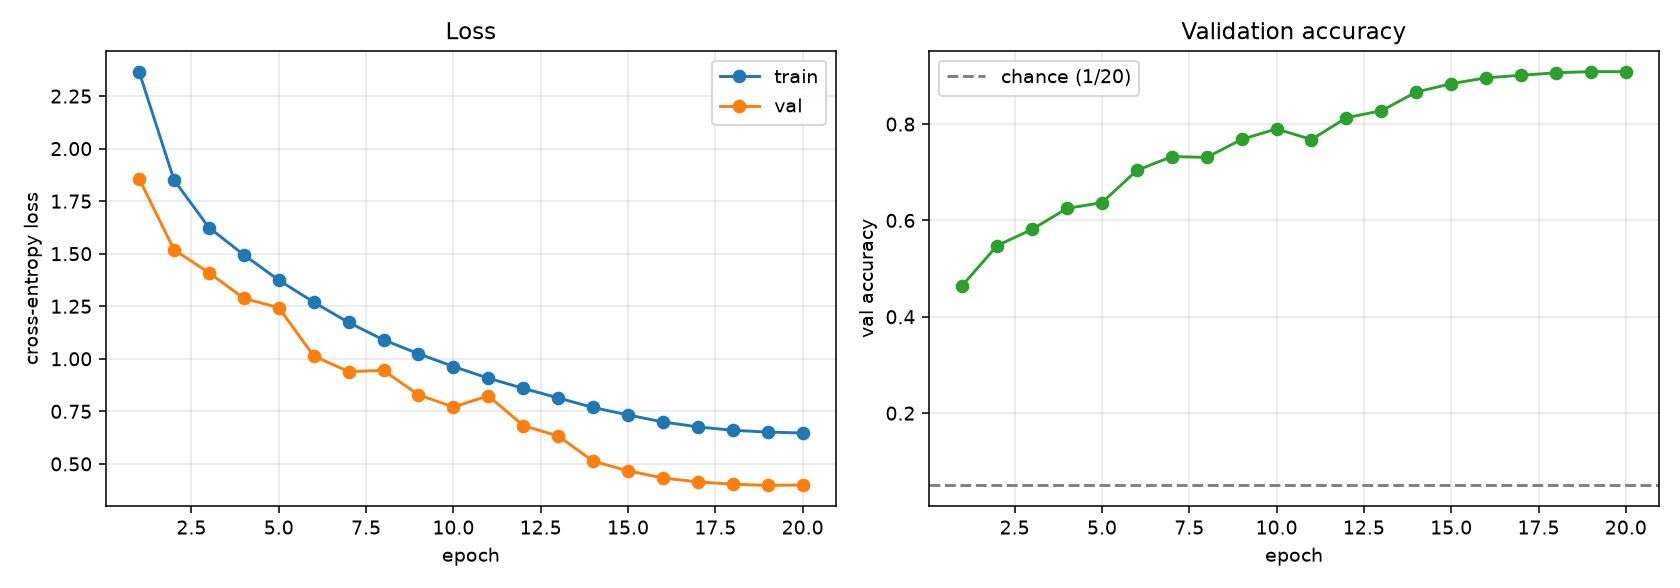

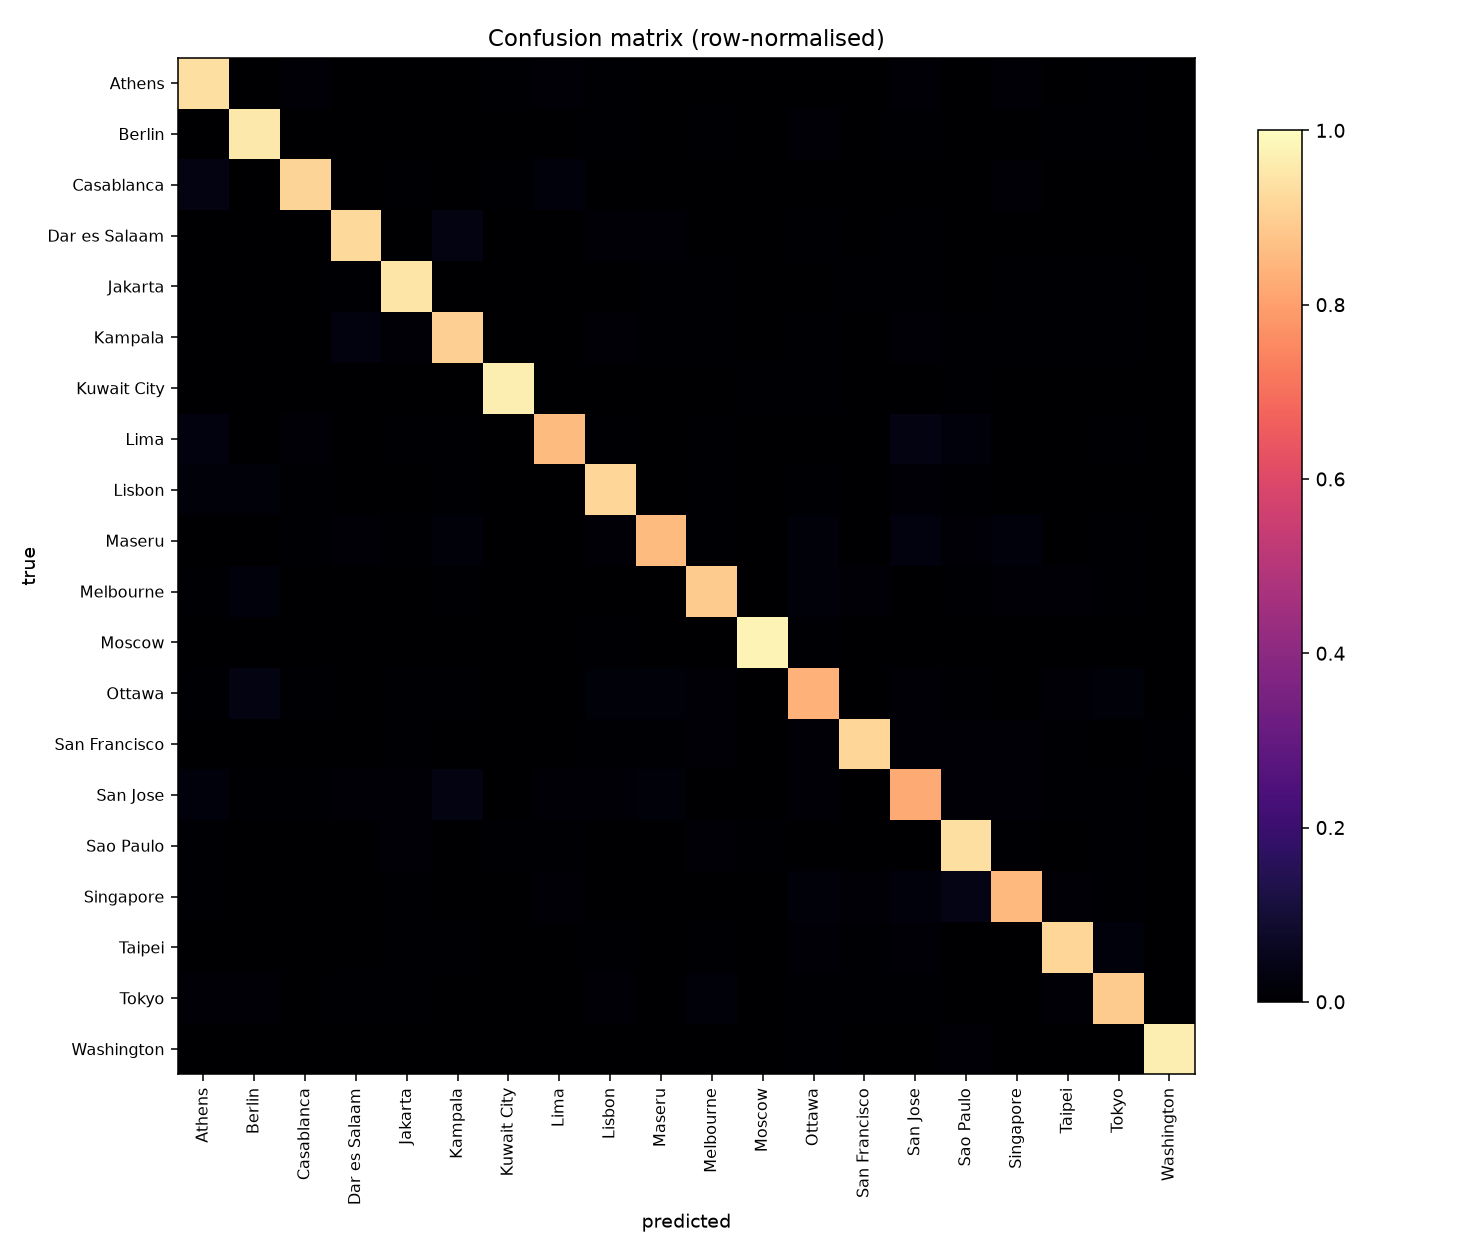

In [5]:
from src.dataset import make_loaders
from src.train import train
from src.viz import plot_history, plot_confusion

if TRAIN_FROM_SCRATCH:
    if IN_COLAB:                           # reduced config that genuinely fits a T4
        cfg["train"].update(cfg["notebook"]["colab_reduced"])
        cfg["dataloader"]["batch_size"] = cfg["notebook"]["colab_reduced"]["batch_size"]
        cfg["dataloader"]["num_workers"] = 2
    set_seed(cfg["project"]["seed"])
    model = build_model(cfg, len(classes))
    train_loader, val_loader = make_loaders(train_df, val_df, classes, cfg)
    history, cm, best = train(model, train_loader, val_loader, cfg, classes, tag="notebook")
    print(f"best val_acc = {best:.4f}")
else:
    h = json.load(open("checkpoints/runA_history.json"))
    history, cm, best = h["history"], h["confusion_matrix"], h["best_val_acc"]
    print(f"published run: best val_acc = {best:.4f}  "
          f"(chance {1/len(classes):.4f}, {best/(1/len(classes)):.1f}x chance)")

display(Image("outputs/runA_curves.png"))
display(Image("outputs/runA_confusion.png"))

In [6]:
# reproducibility, as run locally: two independent runs, same seed
a = json.load(open("checkpoints/runA_history.json"))
b = json.load(open("checkpoints/runB_history.json"))
M = ["train_loss", "val_loss", "val_acc"]
print("all 20 epochs identical on", M, ":",
      all(x[m] == y[m] for x, y in zip(a["history"], b["history"]) for m in M))
print("confusion matrices identical:", a["confusion_matrix"] == b["confusion_matrix"])
wa = torch.load("checkpoints/runA_best.pt", map_location="cpu", weights_only=False)["model"]
wb = torch.load("checkpoints/runB_best.pt", map_location="cpu", weights_only=False)["model"]
print("every weight tensor identical:", all(torch.equal(wa[k], wb[k]) for k in wa))

all 20 epochs identical on ['train_loss', 'val_loss', 'val_acc'] : True
confusion matrices identical: True
every weight tensor identical: True


**90.89% validation accuracy against 5% chance**, on a sequence-disjoint split,
bit-reproducible.

Hold that number lightly. Section 6 shows why, on its own, it establishes very
little.

---
## 4. What did the representation learn?

Two diagnostics on the frozen 2048-d embedding.

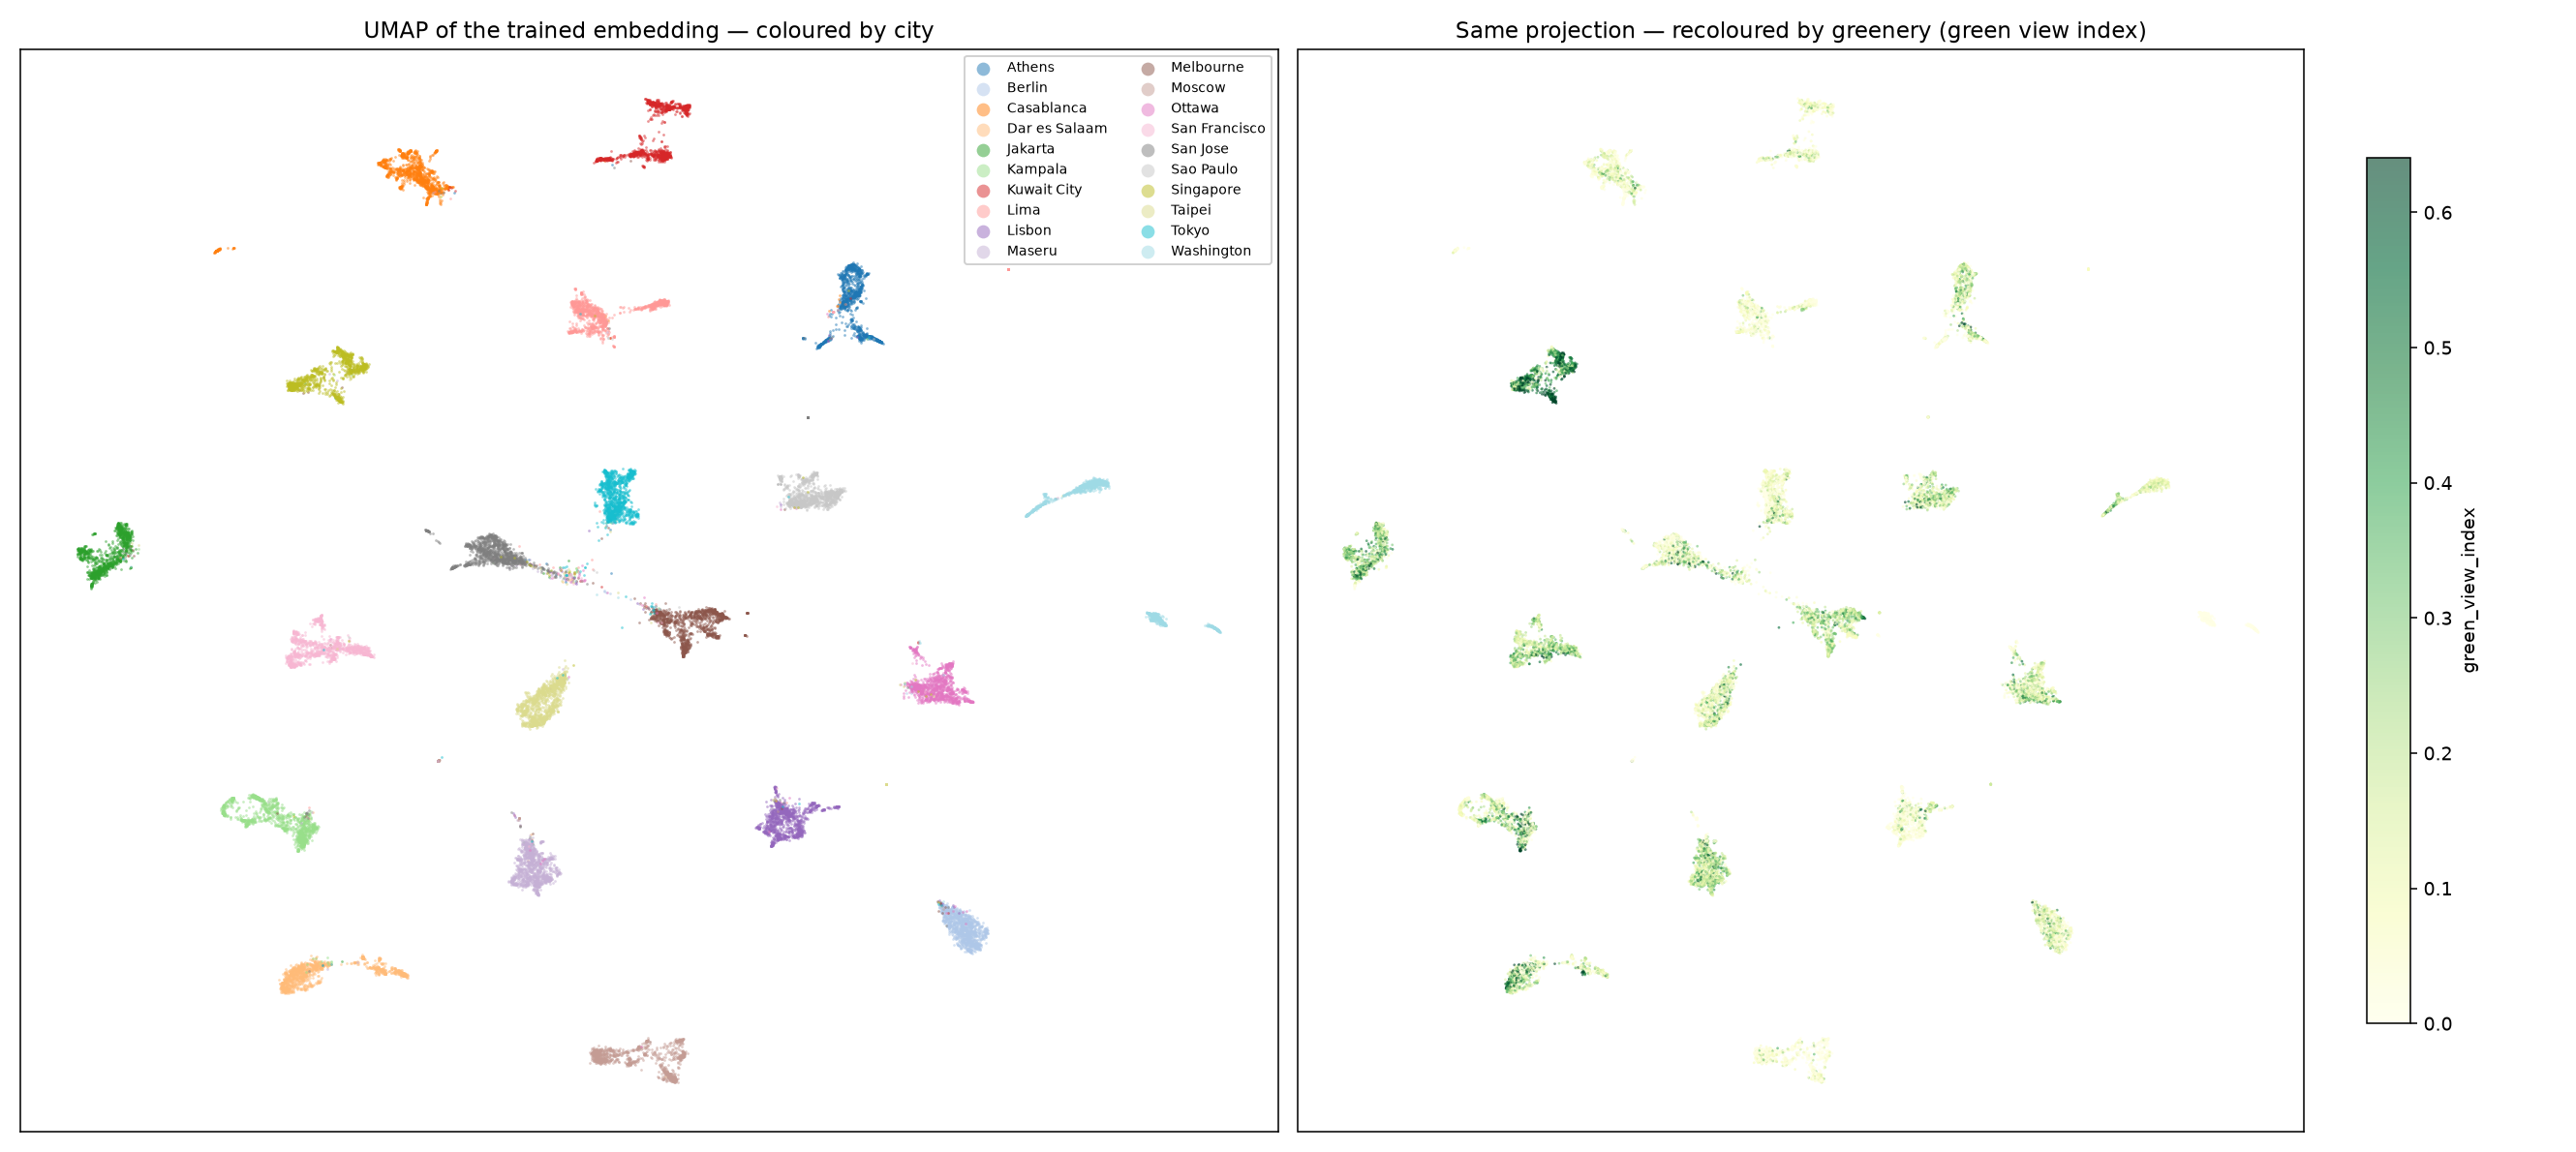

In [7]:
display(Image("outputs/stage8_umap.png"))

**UMAP, coloured by city (left):** twenty tight, almost disjoint islands. The
encoder has partitioned the space by city almost perfectly.

**The same projection recoloured by greenery (right):** greenery is roughly
uniform *within* each island, with no gradient *across* the space. Greenery
varies between clusters only because cities differ in greenery — not because the
embedding organises itself by greenery.

That is a strong hint the embedding is close to a city one-hot: it encodes
*which city*, not *what the street is like*. Which raises an obvious question —
if it separates cities that cleanly, can it find *similar* streets in different
cities? Section 5 tests exactly that.

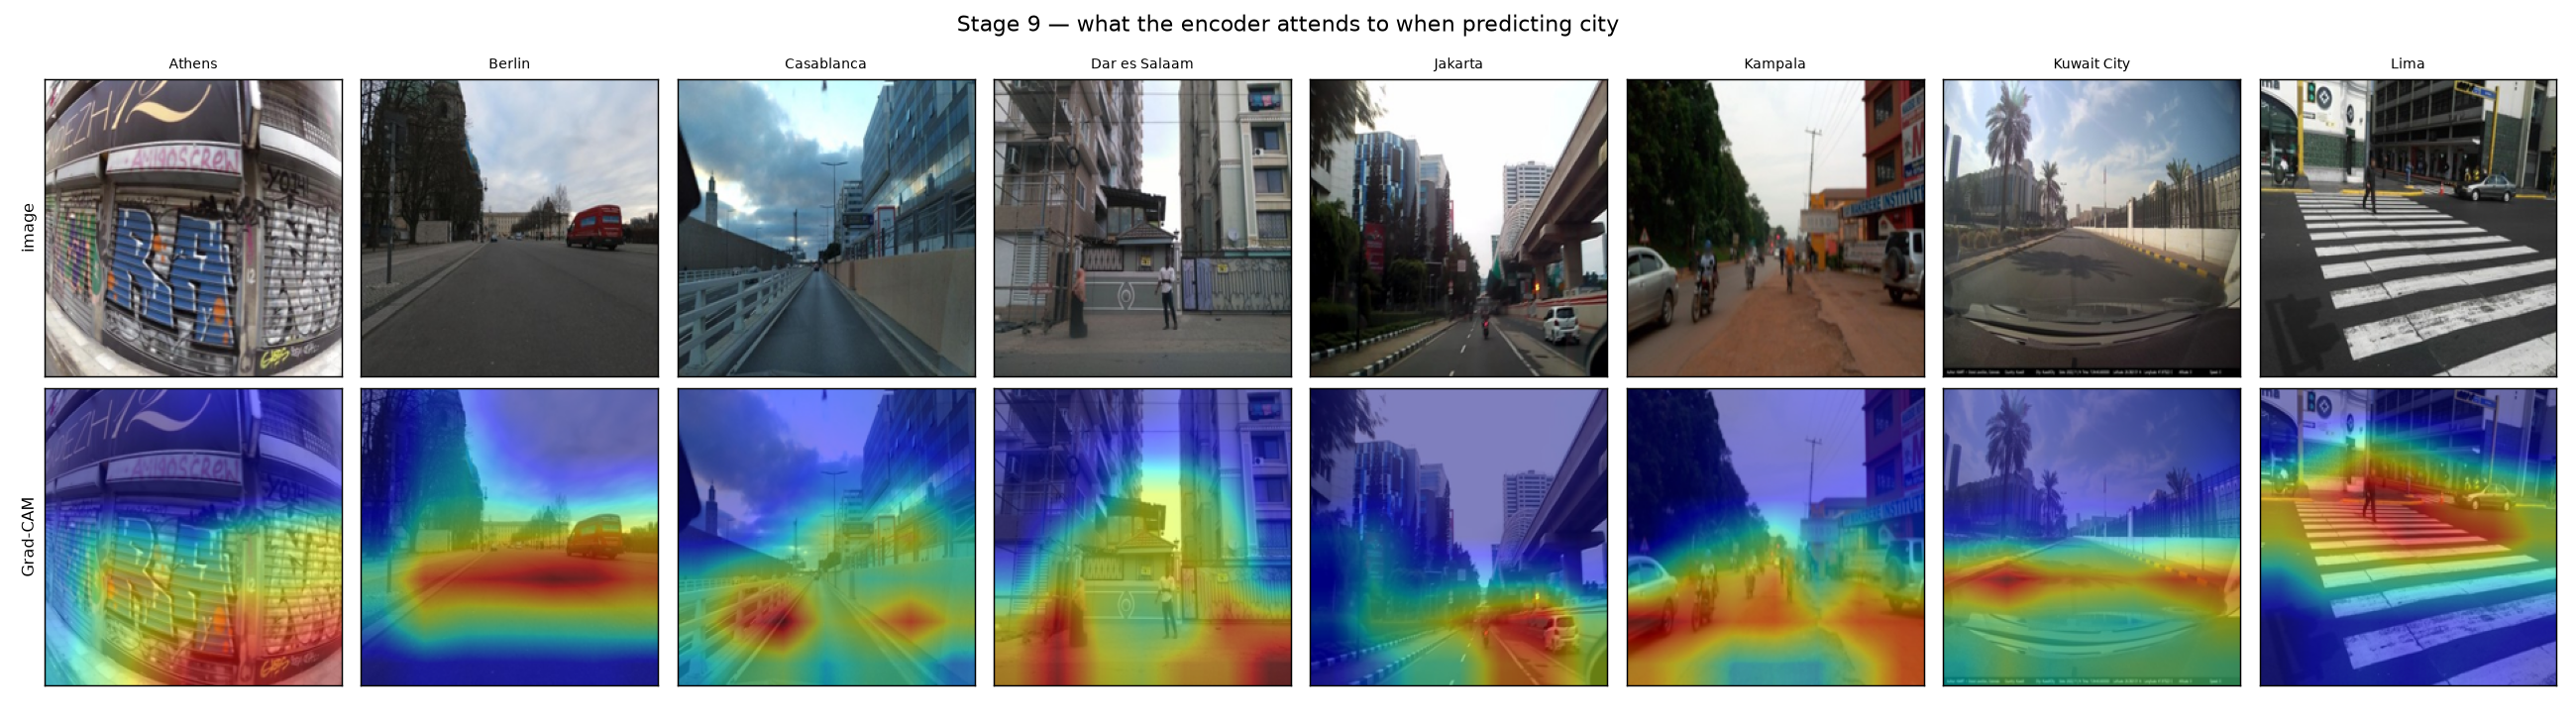

In [8]:
display(Image("outputs/stage9_gradcam.png"))

**Grad-CAM** over the city head. Activation concentrates on road surface and
lane markings (Berlin, Casablanca, Kampala, Jakarta), crosswalk stripes (Lima is
almost entirely zebra markings), and the bottom-of-frame strip where the
dashcam's own text overlay and vehicle bonnet sit (Kuwait City). Comparatively
little lands on buildings, vegetation or skyline.

Road markings and camera furniture are *excellent* city identifiers — they are
standardised nationally and the capture vehicle is often literally the same car.
This is the first concrete evidence that high city accuracy may not be about
urban form.

---
## 5. Cross-city retrieval — the original objective, and how it failed

The project originally set out to find "street doppelgängers": given a street,
retrieve visually similar streets **in other cities**. The metric: for each
query, take the top-10 cross-city neighbours and measure mean absolute
difference in physical attributes the model was never shown, against randomly
paired streets as a control. Lower is better.

### A defect in our own evaluation, and its correction

The original implementation retrieved the **400 globally nearest** candidates and
*then* filtered to other cities. For a representation that clusters cities
tightly, that is degenerate: all 400 nearest neighbours lie in the query's own
city, so the query returns nothing.

Measured on the city encoder, **12 of 20 queries returned zero cross-city
neighbours**, and the average query filled 2.35 of its 10 slots. Its published
score came from 8 queries and ~47 pairs — and those 8 were the biased subset
that happened to sit near a city boundary.

**Stage 7b** corrects this: exclude the query's home city *first*, then take the
true nearest 10 from the entire remaining pool. The original results file is
kept unmodified for reproducibility; the corrected table below is authoritative.

In [9]:
orig = pd.read_csv("outputs/stage7_results.csv")
corr = pd.read_csv("outputs/stage7b_corrected_results.csv").set_index("system")
metrics = ["green_view_index", "building_view_index", "type_highway_mismatch"]
show = corr[[c for c in corr.columns
             if c in metrics or c.endswith(("_ci_lo", "_ci_hi"))]]
print("STAGE 7b — corrected; lower is better; 95% CI from 10,000 query bootstraps\n")
for m in metrics:
    print(f"  {m}")
    for s in corr.index:
        lo, hi = corr.loc[s].get(f"{m}_ci_lo"), corr.loc[s].get(f"{m}_ci_hi")
        ci = f"   [{lo:.4f}, {hi:.4f}]" if pd.notna(lo) else ""
        print(f"    {s:36} {corr.loc[s, m]:.4f}{ci}")
    print()

STAGE 7b — corrected; lower is better; 95% CI from 10,000 query bootstraps

  green_view_index
    Stage 5 city encoder                 0.1344   [0.1133, 0.1548]
    frozen imagenet                      0.0908   [0.0692, 0.1122]
    VICReg ep100                         0.0856   [0.0662, 0.1074]
    tabular (ORACLE-ish sanity check)    0.0240   [0.0171, 0.0325]
    random control                       0.1519

  building_view_index
    Stage 5 city encoder                 0.2226   [0.1821, 0.2630]
    frozen imagenet                      0.1334   [0.1022, 0.1655]
    VICReg ep100                         0.1268   [0.0949, 0.1638]
    tabular (ORACLE-ish sanity check)    0.0362   [0.0286, 0.0444]
    random control                       0.2432

  type_highway_mismatch
    Stage 5 city encoder                 0.3150   [0.2200, 0.4150]
    frozen imagenet                      0.2800   [0.1550, 0.4200]
    VICReg ep100                         0.3600   [0.2400, 0.5000]
    tabular (ORACLE-ish 

**Read honestly:**

- The **city encoder (0.1344 greenery)** is barely better than the random control
  (0.1519). For cross-city physical similarity it is close to useless — and the
  corrected metric now says so using all 20 queries rather than 8.
- **VICReg at epoch 100 (0.0856)** and **frozen ImageNet (0.0908)** are
  **statistically indistinguishable**: paired bootstrap gives 95% CI
  [-0.0222, +0.0136] on greenery, crossing zero. A self-supervised encoder
  trained for 100 epochs (~54 GPU-hours) did **not** significantly beat features
  that were never trained on this data. We report that rather than tuning until
  it wins.
- The **tabular row is an oracle-ish sanity check, not a competitor** — its
  feature vector literally contains the attributes being scored, which is why its
  road-type mismatch is exactly 0.0000.

The one clear, significant result is that both VICReg and frozen ImageNet beat
the *city encoder* on greenery and building density.

In [10]:
import matplotlib.pyplot as plt
d = pd.read_csv("outputs/stage7b_depth_curve.csv")
fig, ax = plt.subplots(figsize=(7.5, 4.2))
for s, g in d.groupby("system"):
    ax.plot(g.depth, g.frac_queries_with_k_plus_cross_city, marker="o", label=s)
ax.set_xscale("log"); ax.set_xlabel("candidate search depth (log scale)")
ax.set_ylabel("fraction of queries with >=10 cross-city neighbours")
ax.set_title("How hard is it to escape your own city?")
ax.grid(alpha=.3); ax.legend(fontsize=8); fig.tight_layout(); plt.show()

/tmp/ipykernel_1134644/3975413583.py:9: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  ax.grid(alpha=.3); ax.legend(fontsize=8); fig.tight_layout(); plt.show()


**This is the striking figure.** For frozen ImageNet, 90% of queries already have
10 cross-city neighbours within the 50 nearest candidates. For the city encoder
you must search past **1,000** candidates before even 35% of queries do.

Under the retrieval objective that was a failure. Under the question this
project actually cares about, it is the phenomenon itself: the encoder has
learned a representation in which a city's streets are overwhelmingly more
similar to each other than to anything elsewhere. That is what a *visual
fingerprint* would look like.

So the question becomes: is that fingerprint the city, or the camera?

---
## 6. Shortcut audit — can we predict the city without looking at the street?

Before celebrating 90.89%, we tested whether city is predictable from **capture
metadata alone**: no pixels, just image dimensions, year, month, hour, source and
projection type, on the same sequence-disjoint split.

In [11]:
aud = json.load(open("outputs/shortcut_audit.json"))
for r in aud["metadata_only"]:
    print(f"  metadata only — {r['subset']:32} {r['metadata_only_acc']:.4f}  (n={r['n']:,})")
print(f"\n  Stage 5 PIXEL encoder                          0.9063")
print(f"  chance                                         0.0500")
print("\n  which metadata features carry the signal:")
for k, v in aud["permutation_importance"].items():
    print(f"    {k:20} {v:+.4f}")

  metadata only — current dataset (all)            0.9249  (n=100,000)
  metadata only — perspective only                 0.9211  (n=78,043)
  metadata only — perspective + years 2018-2022    0.9081  (n=50,825)

  Stage 5 PIXEL encoder                          0.9063
  chance                                         0.0500

  which metadata features carry the signal:
    year                 +0.5068
    month                +0.4443
    width                +0.2453
    height               +0.1738
    hour                 +0.1684
    proj_fisheye         +0.1266


**Capture metadata alone reaches 0.9233 — higher than the pixel encoder's
0.9063.**

The signal is dominated by **year (+0.50)** and **month (+0.45)**. The 20 cities
were collected as distinct campaigns: Casablanca is 92.7% a single year *and*
92.7% a single month; Lima 85% one year; Kuwait City 84%. Fisheye share ranges
from 0.000 (8 cities) to 0.837 (Taipei).

Stratifying does not remove it — perspective-only is still 0.9211, and
perspective restricted to 2018–2022 still 0.9081. The confound is structural.

**Therefore classification accuracy alone cannot establish that the encoder
learned urban character.** It does not prove the CNN used those cues — it cannot
see `width` directly — but it can see lens distortion, compression, colour
science, sun angle and vegetation phenology, all of which are campaign
signatures. Combined with the Grad-CAM evidence, the 90.89% is not by itself
evidence of anything about cities.

---
## 7. A clean cross-campaign diagnostic

If the encoder had merely learned *when* each city was photographed, it should
fail when tested on a different capture period. So: train a linear probe on the
frozen embedding using each city's **early** capture period, and test it on a
**disjoint later** period.

### The first version of this test was contaminated — and we are keeping that

Our first run reported **0.9682**, which looked like a triumph. It was not.
The campaign split was drawn from the full dataset without regard to the
encoder's *own* train/val split, so **80.9% of the late-test images had already
been used to train the encoder, with city labels**. It could not demonstrate
generalisation to an unseen campaign, and we do not use it as a headline.

The authoritative test uses only late-campaign images that fell in the encoder's
validation split — images it **never saw during training**.

In [12]:
prov = json.load(open("outputs/experiment1_provenance.json"))
exp1 = json.load(open("outputs/experiment1_cross_campaign.json"))
print("CONTAMINATED first attempt (NOT used as a result)")
print(f"  Stage 5 probe, late test with 80.9% seen in training   {exp1['B_cross_campaign']:.4f}  <-- discarded\n")
print("AUTHORITATIVE clean cross-campaign diagnostic")
print(f"  test set: {prov['clean_late_n']:,} unseen images / "
      f"{prov['clean_late_seqs']:,} sequences / 19 cities")
print(f"  Stage 5 visual representation                          {prov['stage5_probe_clean']:.4f}")
print(f"  metadata only, same clean test                         {prov['metadata_clean']:.4f}")
print(f"  chance                                                 {prov['chance']:.4f}")

CONTAMINATED first attempt (NOT used as a result)
  Stage 5 probe, late test with 80.9% seen in training   0.9682  <-- discarded

AUTHORITATIVE clean cross-campaign diagnostic
  test set: 8,268 unseen images / 1,350 sequences / 19 cities
  Stage 5 visual representation                          0.8892
  metadata only, same clean test                         0.1160
  chance                                                 0.0500


| | accuracy |
|---|---:|
| **Stage 5 visual representation** | **0.8892** |
| Metadata only, same clean test | 0.1160 |
| Chance | 0.0500 |

*8,268 unseen images / 1,350 sequences / 19 cities.*

The metadata model collapses from 0.9233 to 0.1160 once it must generalise
across capture periods, while the visual representation holds at 0.8892.

**The dominant temporal/capture metadata confound does not explain the encoder's
performance on the clean cross-campaign subset.**

That is a deliberately narrow claim. Two limitations qualify it:

- **Contributor and camera continuity is unresolved.** The split controls for
  *when*, not *who*. If the same contributor drove a city with the same camera in
  both periods, that artefact persists across the holdout. Contributor identity
  is not available in our cached fields.
- **The effective sample size is sequences, not images.** 8,268 images come from
  1,350 sequences, so the estimate is more uncertain than the image count
  suggests.

---
## 8. What makes a city look like itself?

Now the payoff. We rank every image by how **characteristic** it is of its own
city, according to the encoder.

### The characteristic score, intuitively

A naive approach ranks images by closeness to their city's average embedding.
But that rewards images that are merely *typical* — a generic road looks like the
average of most cities, and would score well everywhere.

What we want is images that are typical of **this** city *and unlike every other
city*. So we use a **margin**: how much more like its own city an image looks
than like its closest rival city.

$$\text{score}(x) = \cos(x, \mu_{\text{own}}) - \max_{c \neq \text{own}} \cos(x, \mu_c)$$

where $\mu_c$ is the mean embedding of city $c$. High = characteristic and
distinctive; low or negative = an image that, to the model, does not look like
its own city.

margin range across all 100,000 images: -0.465 .. 0.631


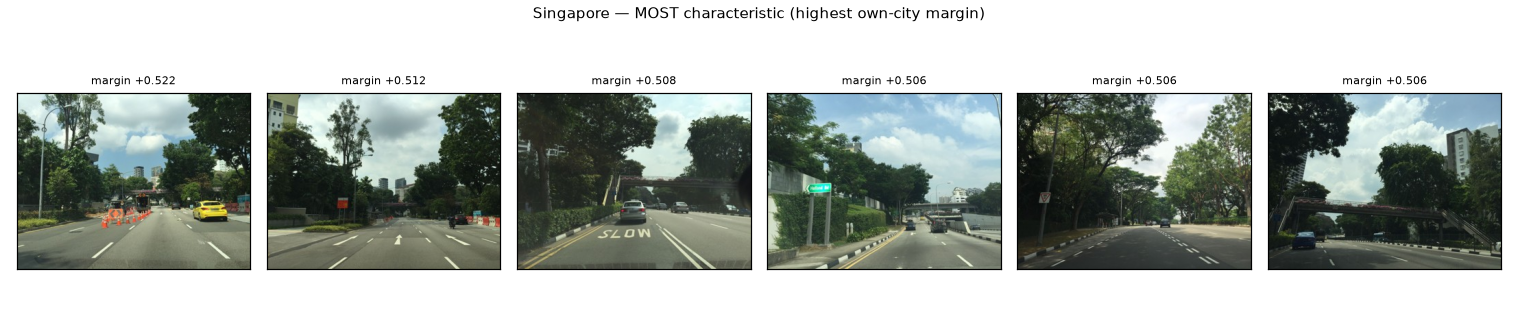

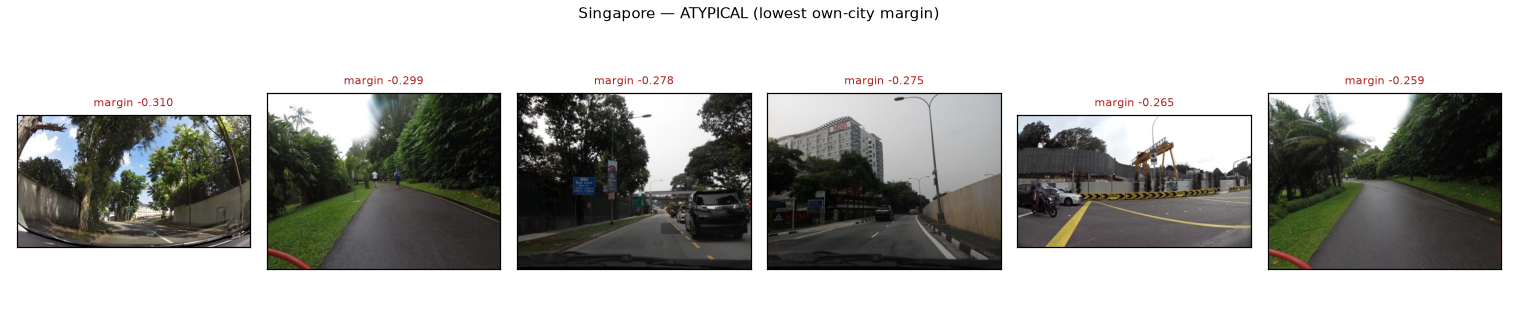

In [13]:
sig = pd.read_csv("outputs/signatures/characteristic_atypical.csv")
print("margin range across all 100,000 images: "
      f"{sig.margin.min():.3f} .. {sig.margin.max():.3f}")
display(Image("outputs/signatures/Singapore_characteristic.png"))
display(Image("outputs/signatures/Singapore_atypical.png"))

### Singapore, worked through

**Characteristic** — and importantly, these are *ordinary streets, not landmarks*:
dense roadside tree canopy arching over multi-lane carriageways, mown green
verges, tropical planting, green directional signage. That is a recognisable
description of everyday Singapore road corridors, and the model arrived at it
without ever being told about vegetation.

**Atypical** — park and footpaths, construction hoarding, cluttered commercial
frontage: Singapore images that lack the canopied-arterial character. Note
several also show a **different capture platform** (fisheye distortion, a
bicycle handlebar cable visible at the frame edge). So the margin score is
partly sensitive to camera rig, not only to urban form — exactly the kind of
honesty the confound audit demands.

### Model-discovered visual modes

A city rarely has one look. Within each city we cluster the embeddings into
three groups and show exemplars. These are **model-discovered visual modes** —
whatever structure this particular embedding happens to carry — **not** objective
urban archetypes.

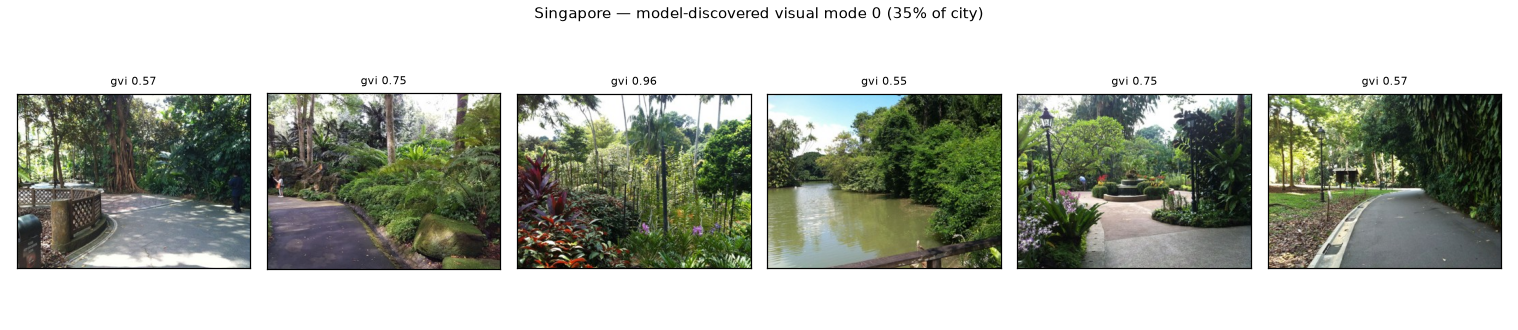

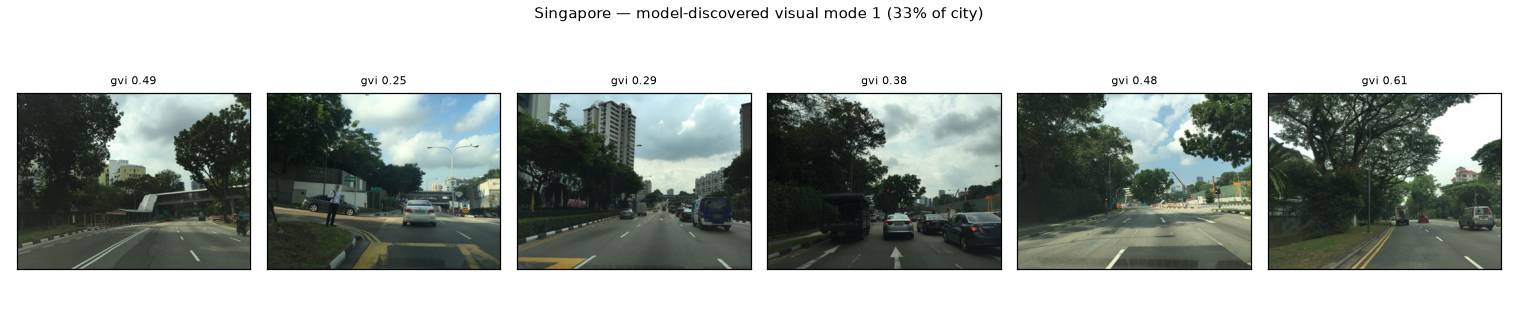

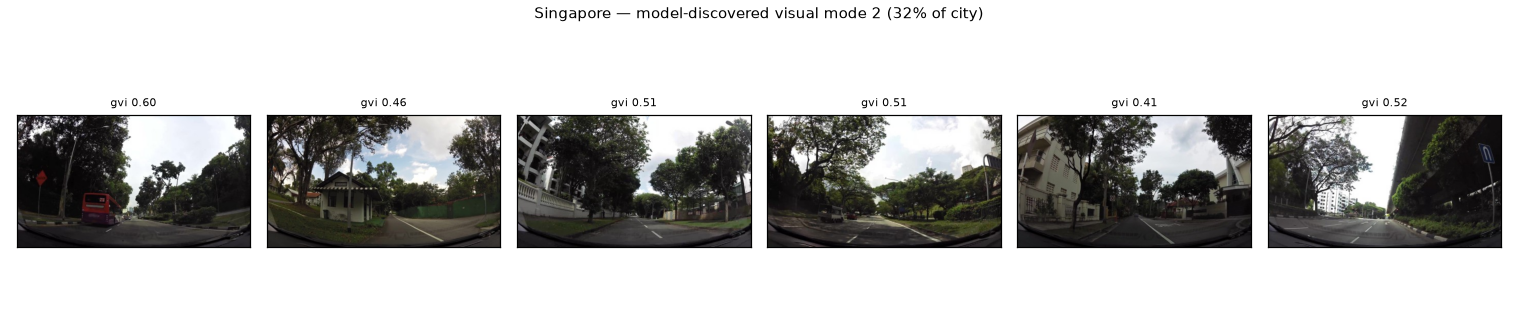

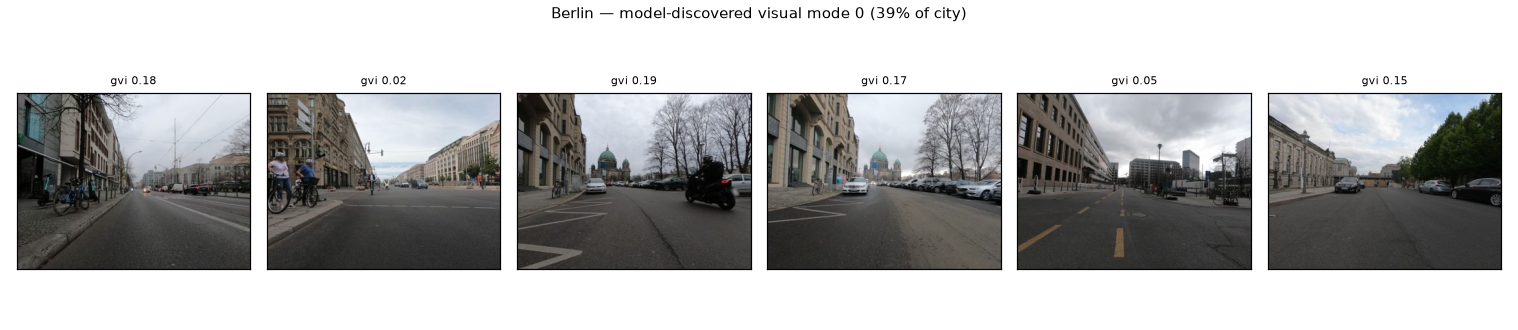

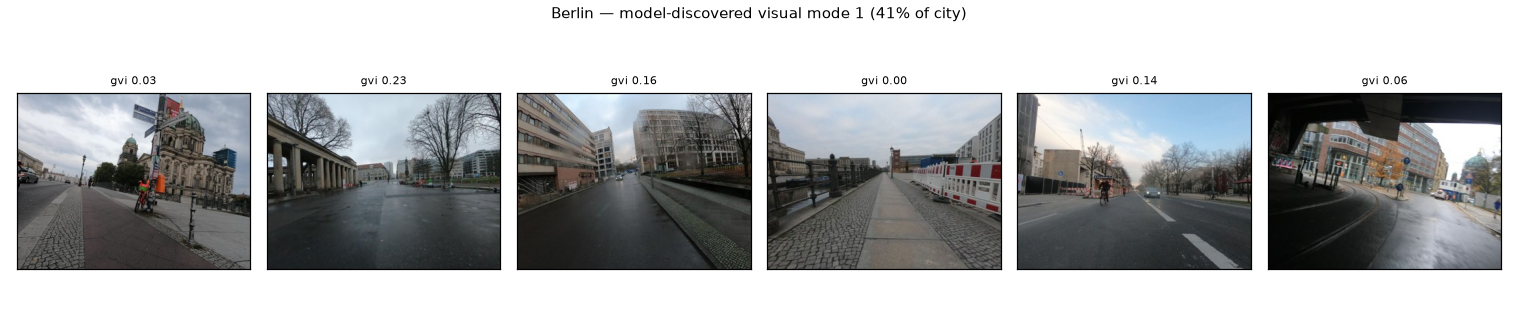

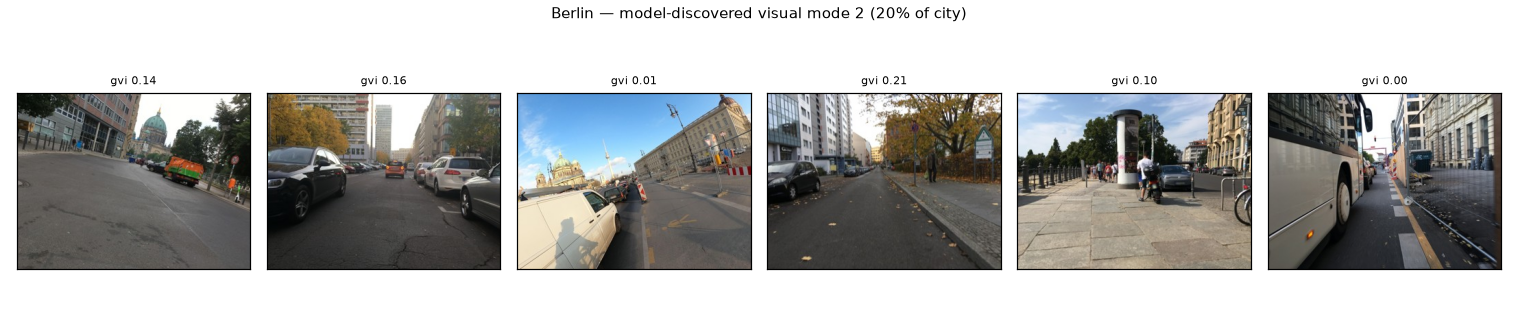

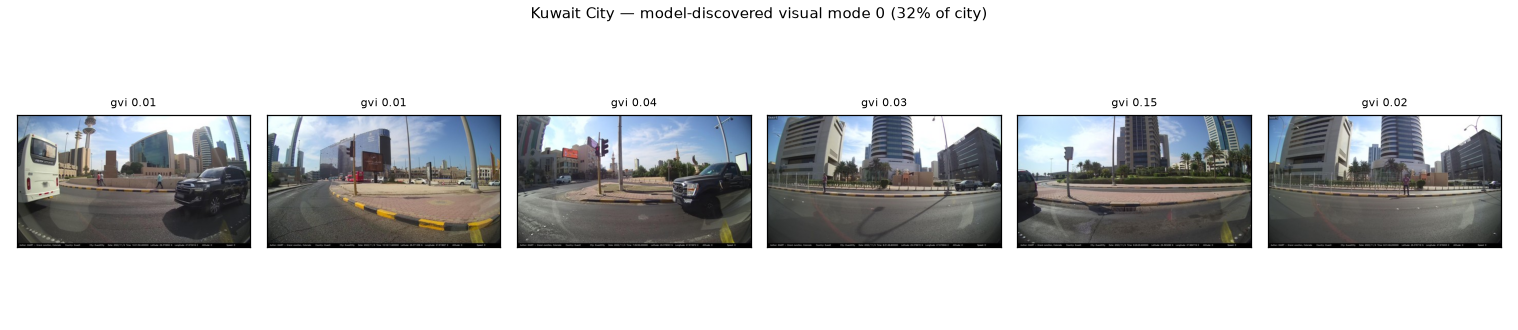

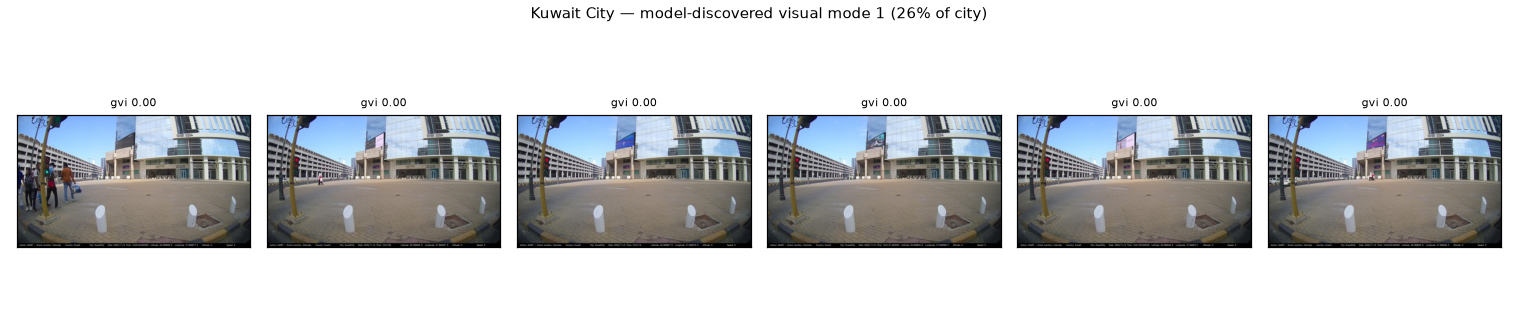

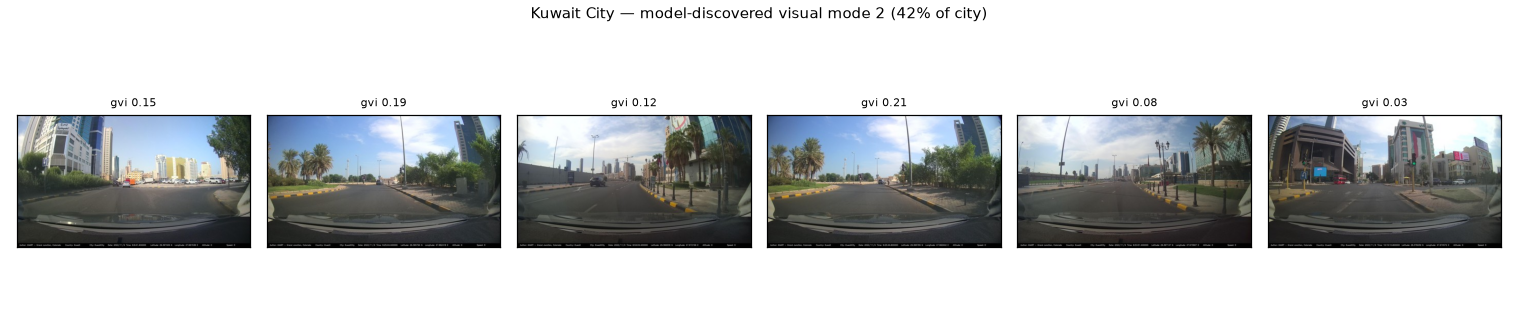

In [14]:
for c in ["Singapore", "Berlin", "Kuwait City"]:
    s = c.replace(" ", "_")
    for m in range(3):
        p = f"outputs/signatures/{s}_mode{m}.png"
        if os.path.exists(p):
            display(Image(p))

In [15]:
modes = pd.read_csv("outputs/signatures/mode_summary.csv")
cols = ["city", "mode", "share", "green_view_index", "building_view_index",
        "top_road", "top_year", "top_year_share", "confound_flag"]
sel = modes[modes.city.isin(["Singapore", "Berlin", "Kuwait City", "Moscow"])]
print(sel[cols].round(3).to_string(index=False))

       city  mode  share  green_view_index  building_view_index top_road  top_year  top_year_share             confound_flag
     Berlin     0  0.389             0.082                0.224    drive      2022           0.407                         -
     Berlin     1  0.408             0.099                0.208    drive      2022           0.448                         -
     Berlin     2  0.203             0.116                0.217    drive      2022           0.410                         -
Kuwait City     0  0.321             0.077                0.170    drive      2022           0.788                         -
Kuwait City     1  0.264             0.088                0.210    drive      2022           0.655                         -
Kuwait City     2  0.415             0.057                0.170    drive      2022           1.000                         -
     Moscow     0  0.453             0.035                0.250    drive      2020           0.601                         -


---
## 9. Confound-aware interpretation

For every mode we summarise interpretable physical attributes (greenery,
building density, road type) **alongside** capture variables (year, month, hour,
source, projection type). A mode that is really "one camera on one trip" should
be visible as such rather than described as urban character.

The flag measures **excess concentration over the city's own baseline**, not raw
concentration. A city that is 100% perspective imagery will have every mode at
100% perspective — that says nothing. What matters is a mode being far more
concentrated than its city as a whole. (Our first version measured raw
concentration and over-flagged 9 of 12 modes for precisely this reason.)

In [16]:
flagged = modes[modes.confound_flag != "-"]
print(f"{len(flagged)} of {len(modes)} modes flagged\n")
print(flagged[["city", "mode", "share", "confound_flag"]].round(3).to_string(index=False))

14 of 60 modes flagged

         city  mode  share                                      confound_flag
       Athens     0  0.409                                       month(+0.30)
       Athens     2  0.199                                       month(+0.64)
   Casablanca     0  0.089             year(+0.70), month(+0.70), hour(+0.63)
Dar es Salaam     1  0.500                          year(+0.21), month(+0.27)
      Jakarta     1  0.438 year(+0.27), source(+0.21), projection_type(+0.34)
      Jakarta     2  0.258                             projection_type(+0.54)
      Kampala     2  0.312                          year(+0.37), month(+0.37)
       Lisbon     2  0.126               month(+0.53), projection_type(+0.23)
    Melbourne     0  0.401                             projection_type(+0.25)
    Melbourne     1  0.248                             projection_type(+0.44)
San Francisco     0  0.321                                       month(+0.30)
    Sao Paulo     1  0.158              

**14 of 60 modes are flagged.** Examples:

- **Casablanca mode 0** — year +0.70, month +0.70, hour +0.63. Essentially a
  single collection trip; it should not be read as a Casablanca street type.
- **Singapore mode 2** — year +0.56, month +0.53. 95% one year, where the city's
  most common year is only 40%.
- **Jakarta mode 1** — year +0.27, source +0.21, projection +0.34. A camera and
  platform signature as much as an urban one.
- **Melbourne mode 1** — projection +0.44. Largely a lens-type cluster.

**46 of 60 modes are not flagged by this test.** That phrasing is deliberate.
They are **not proven** to be intrinsic city characteristics. The correct reading
is that these modes **support a visual-signature interpretation under the
confounds we measured** — a test can only rule out the artefacts it looks for,
and contributor identity was not among them.

---
## 10. Conclusion

Three distinct findings, which should not be collapsed into one.

**1. A city-supervised encoder learns a strongly city-discriminative
representation.** 90.89% against 5% chance on a sequence-disjoint split,
bit-reproducible. UMAP shows near-disjoint city islands, and cross-city
neighbours are so scarce that a search must pass 1,000 candidates before a third
of queries find ten.

**2. That representation is poorly suited to cross-city physical similarity.**
On the corrected Stage 7b evaluation it is barely better than random at
retrieving streets matching on greenery, building density or road type — and
significantly worse than both frozen ImageNet and VICReg. Training a
self-supervised encoder for 100 epochs did **not** significantly beat frozen
ImageNet features on that objective. City discrimination and cross-city
similarity turn out to be close to opposed objectives: the first rewards what
separates cities, the second needs what they share.

**3. On genuinely unseen later imagery, substantial city-discriminative visual
signal remains after the dominant metadata shortcut collapses.** 0.8892 versus a
metadata baseline that falls to 0.1160. This permits *cautious* inspection of the
visual signatures the model associates with each city — canopied arterials for
Singapore, and so on — while 14 of 60 modes remain visibly tied to capture
artefacts.

The distinction we have tried to hold throughout: **what the model has learned to
associate with city identity** is not the same as **what we can prove is
intrinsic to the city**. This notebook establishes the first and is careful about
the second.

---
## 11. Limitations

- **Only 20 cities**, 5,000 images each. Nothing here generalises to the 688
  cities in the full dataset.
- **Collection and campaign bias is severe.** Cities were photographed in
  distinct periods with distinct equipment; capture metadata alone predicts city
  at 0.9233. The cross-campaign diagnostic addresses the temporal part of this,
  not all of it.
- **Contributor identity is unavailable** in our cached fields, so we cannot rule
  out a contributor using the same camera across both capture periods. This is
  the most important unresolved confound.
- **"Characteristic" and "model-discovered" do not mean causal**, nor uniquely
  intrinsic to a city. They describe what this encoder associates with city
  identity.
- **Physical attributes explain only part of the embedding.** Greenery, building
  density and road type are three coarse numbers; much of what the encoder
  encodes is not captured by them.
- **The cross-city retrieval evaluation uses only 20 queries.** Confidence
  intervals are correspondingly wide, which is why VICReg vs frozen ImageNet is
  reported as not significant rather than as a small win.
- **Casablanca is absent from the clean late-campaign test** — it had no
  late-period images outside the encoder's training set, so that diagnostic
  covers 19 of 20 cities.
- **Panoramas were excluded**, so conclusions apply to perspective and fisheye
  street-level imagery only.